In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc,
                              classification_report)

In [15]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [16]:
df = df.drop(columns=[c for c in ["id", "Unnamed: 32"] if c in df.columns])

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # M -> 1, B -> 0

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print(X.shape)
print(y.value_counts())

(569, 30)
diagnosis
0    357
1    212
Name: count, dtype: int64


# Correlation heatmap
just to sanity check which features move together before modeling

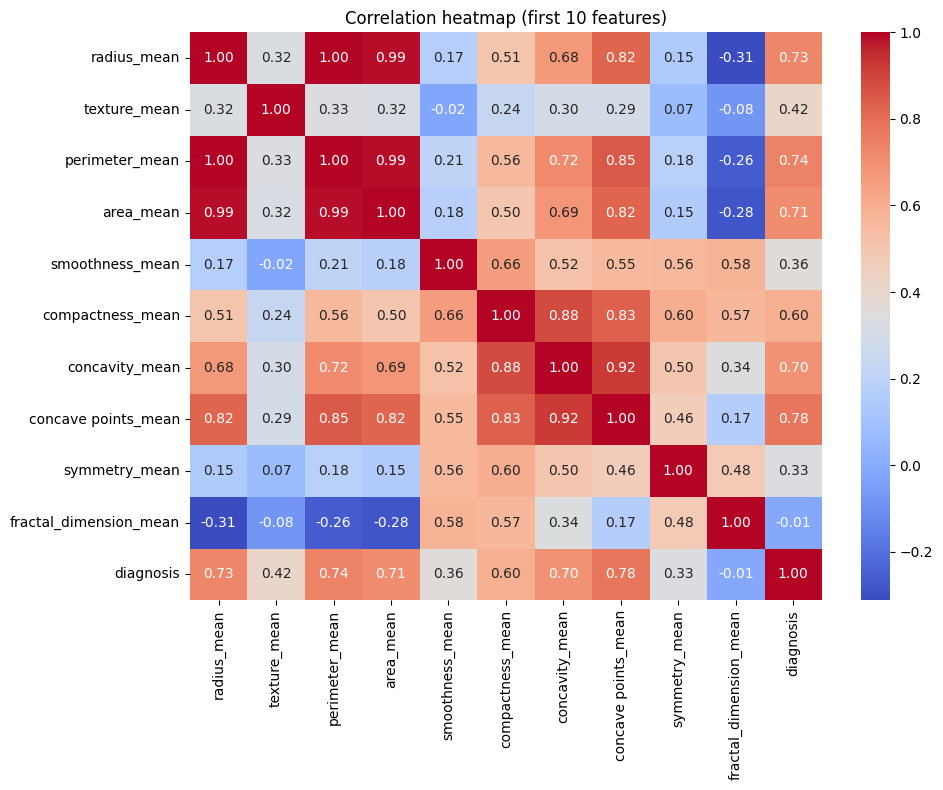

In [17]:
plt.figure(figsize=(10, 8))
corr = X.iloc[:, :10].copy()
corr["diagnosis"] = y
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap (first 10 features)")
plt.tight_layout()
plt.show()

scaling everything since the models are sensitive to feature values

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Build the stacking model

In [19]:
base_learners = [
    ("logreg", LogisticRegression(max_iter=5000)),
    ("knn", KNeighborsClassifier(n_neighbors=7)),
    ("dtree", DecisionTreeClassifier(max_depth=5, random_state=42)),
]

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5,
    passthrough=False,
)

stack_model.fit(X_train_scaled, y_train)
y_pred = stack_model.predict(X_test_scaled)
y_proba = stack_model.predict_proba(X_test_scaled)[:, 1]

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Stacking Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Compare base models vs. the stack

In [20]:
print("Cross-validated accuracy comparison:")
for name, model in base_learners + [("stacking", stack_model)]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross-validated accuracy comparison:
logreg: 0.9714 (+/- 0.0112)
knn: 0.9692 (+/- 0.0235)
dtree: 0.9341 (+/- 0.0326)
stacking: 0.9692 (+/- 0.0224)


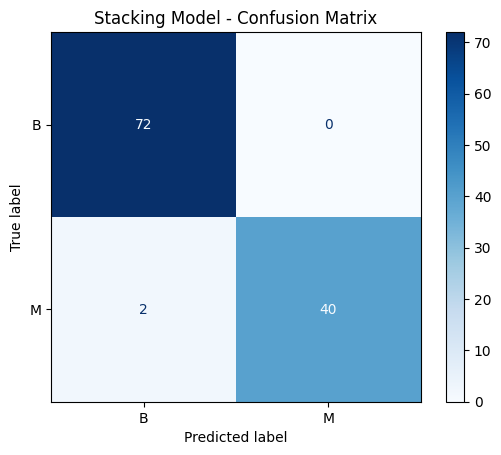

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Stacking Model - Confusion Matrix")
plt.show()

## ROC curve

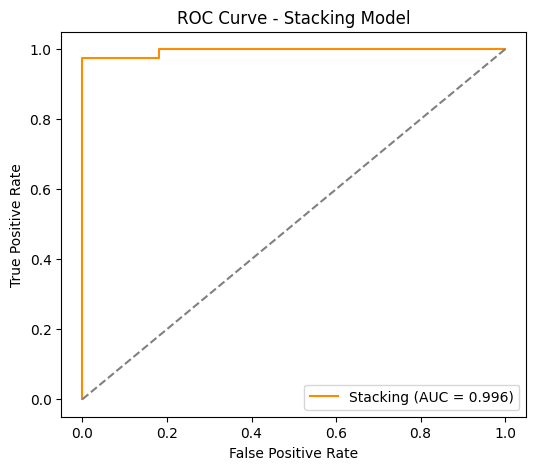

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Stacking (AUC = {roc_auc:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Model")
plt.legend()
plt.show()

 Accuracy comparison bar chart


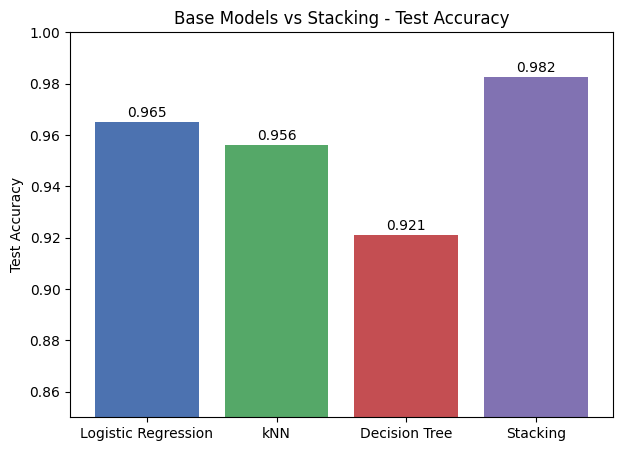

In [23]:
model_names = ["Logistic Regression", "kNN", "Decision Tree", "Stacking"]
accuracies = []
for name, model in base_learners:
    model.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))
accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, accuracies, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.ylim(0.85, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Base Models vs Stacking - Test Accuracy")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.002, f"{acc:.3f}", ha="center")
plt.show()

## as we see: the stacking model outperfoms all even tho not by a very large margin